# Visibility Graphs
## An alternative pipeline from time series to TDA

The Takens embedding converts a time series into a point cloud via sliding windows. **Visibility graphs** offer a fundamentally different approach — mapping the time series directly to a graph, then using the graph's dissimilarity matrix as input for TDA.

This approach, explored in Güzel (2026), avoids the embedding dimension problem entirely — no FNN, no parameter selection. The topology of the time series is captured through the **connectivity structure** of the graph.

## Natural Visibility Graph (NVG)

Given a time series $\{r_t\}$, two points $(t_a, r_a)$ and $(t_b, r_b)$ are connected by an edge if and only if for all intermediate points $t_c$ with $t_a < t_c < t_b$:

$$r_c < r_a + (r_b - r_a)\frac{t_c - t_a}{t_b - t_a}$$

Geometrically — two bars in a bar chart **see each other** if no intermediate bar blocks the line of sight between them.

## Horizontal Visibility Graph (HVG)

A simpler construction — two points $(t_a, r_a)$ and $(t_b, r_b)$ are connected if and only if:

$$r_c < \min(r_a, r_b) \quad \forall t_c \text{ with } t_a < t_c < t_b$$

HVG is a subgraph of NVG — strictly more restrictive.

In [1]:
import sys
sys.path.insert(0, '/home/gabo-linux/TDA-Gabo/tda-financial-data-pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed normalized returns
sp500 = pd.read_csv('../data/processed/sp500_returns_normalized.csv',
                    index_col=0, parse_dates=True).squeeze()
tsla = pd.read_csv('../data/processed/tsla_returns_normalized.csv',
                   index_col=0, parse_dates=True).squeeze()
btc = pd.read_csv('../data/processed/btc_returns_normalized.csv',
                  index_col=0, parse_dates=True).squeeze()

print(f"S&P 500: {len(sp500)} days")
print(f"TSLA:    {len(tsla)} days")
print(f"BTC:     {len(btc)} days")

S&P 500: 6036 days
TSLA:    3399 days
BTC:     3392 days


In [2]:
def natural_visibility_graph(series):
    """
    Construct the Natural Visibility Graph (NVG) from a time series.
    
    Parameters
    ----------
    series : np.ndarray
        1D time series
    
    Returns
    -------
    G : networkx.Graph
    """
    n = len(series)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            visible = True
            for k in range(i + 1, j):
                # Check visibility condition
                interpolated = series[i] + (series[j] - series[i]) * (k - i) / (j - i)
                if series[k] >= interpolated:
                    visible = False
                    break
            if visible:
                G.add_edge(i, j)
            else:
                break
    return G

In [3]:
def horizontal_visibility_graph(series):
    """
    Construct the Horizontal Visibility Graph (HVG) from a time series.
    
    Parameters
    ----------
    series : np.ndarray
        1D time series
    
    Returns
    -------
    G : networkx.Graph
    """
    n = len(series)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            # Check horizontal visibility condition
            min_val = min(series[i], series[j])
            visible = all(series[k] < min_val for k in range(i + 1, j))
            if visible:
                G.add_edge(i, j)
            else:
                break
    return G

## Testing on a Small Window

Visibility graph construction is $O(n^2)$ — running on the full 6000-day series would be computationally prohibitive. We first validate the implementation on a small window of 50 days, then discuss efficient strategies for the full dataset.

In [4]:
# Test on 50 days around the 2008 crisis
window = sp500['2008-09-01':'2008-11-01'].values[:50]

print(f"Window size: {len(window)} days")

# Build graphs
G_nvg = natural_visibility_graph(window)
G_hvg = horizontal_visibility_graph(window)

print(f"NVG edges: {G_nvg.number_of_edges()}")
print(f"HVG edges: {G_hvg.number_of_edges()}")

Window size: 44 days
NVG edges: 75
HVG edges: 62


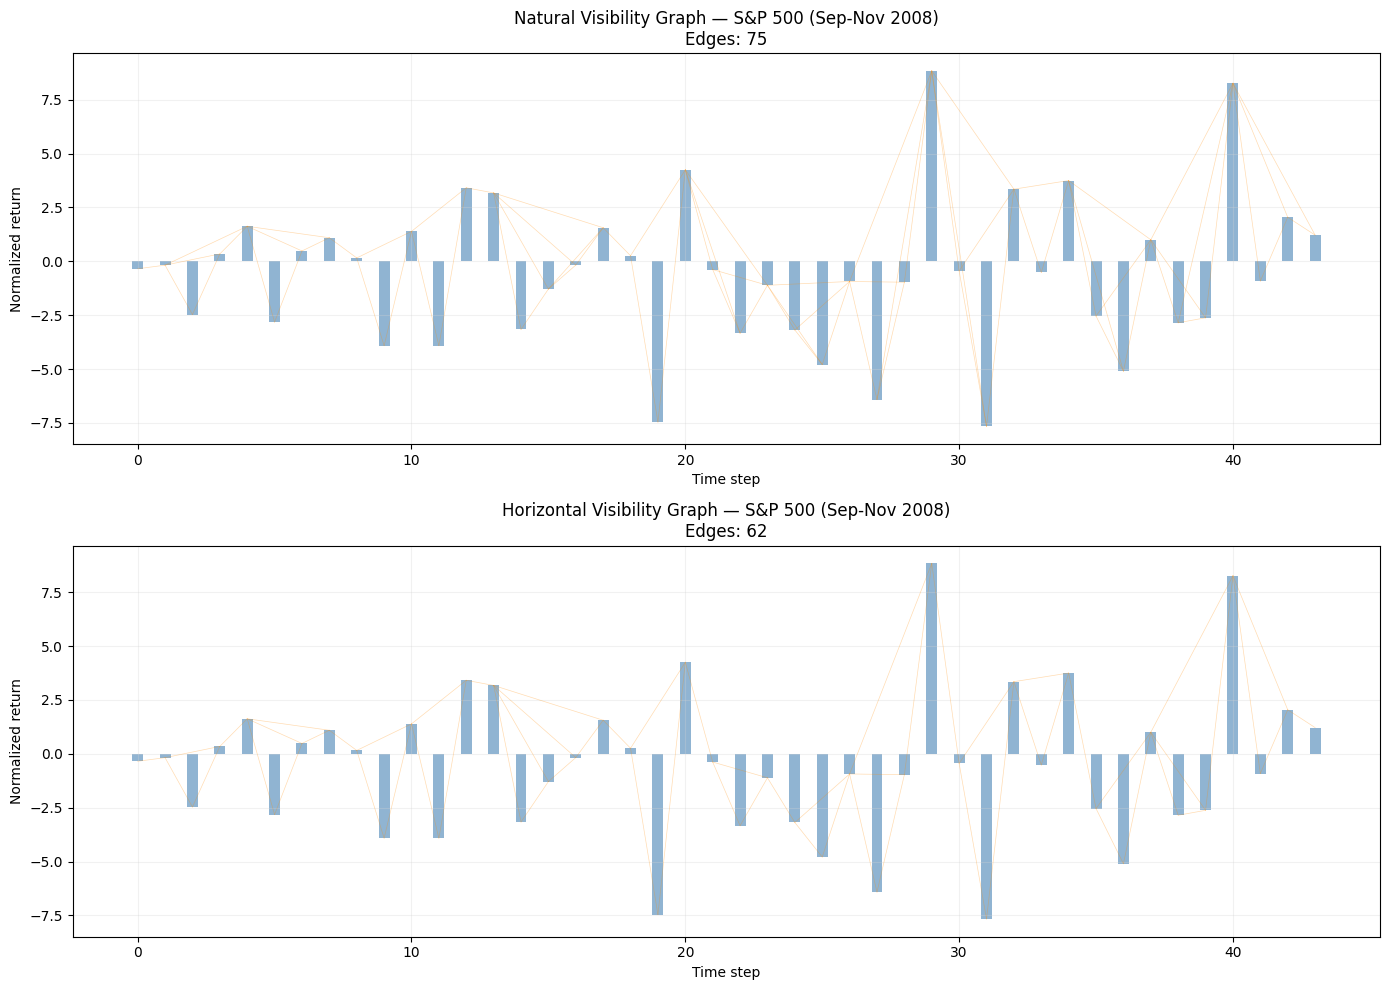

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor='white')

dates = sp500['2008-09-01':'2008-11-01'].index[:44]

for ax, (G, title) in zip(axes, [(G_nvg, 'Natural Visibility Graph'), 
                                   (G_hvg, 'Horizontal Visibility Graph')]):
    ax.set_facecolor('white')
    
    # Plot return series as bars
    ax.bar(range(len(window)), window, color='steelblue', alpha=0.6, width=0.4)
    
    # Draw edges
    for edge in G.edges():
        i, j = edge
        ax.plot([i, j], [window[i], window[j]], 
                color='darkorange', alpha=0.3, linewidth=0.5)
    
    ax.set_title(f'{title} — S&P 500 (Sep-Nov 2008)\nEdges: {G.number_of_edges()}')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Normalized return')
    ax.grid(alpha=0.3, color='lightgrey')

plt.tight_layout()
plt.show()

## Observations

**NVG** — extreme returns during the 2008 crisis become **high-degree hubs**, connecting to many distant points they can "see" over shorter intermediate bars.

**HVG** — extreme returns act as **barriers**, blocking horizontal visibility and isolating neighboring periods from each other.

Both capture different structural properties of the crisis period — NVG emphasizes long-range dependencies, HVG emphasizes local structure.

## Dissimilarity Matrix

To apply Vietoris-Rips filtration we need a **dissimilarity matrix** — a pairwise distance matrix between all nodes. We use the **shortest path distance** between nodes in the graph:

$$D_{ij} = \text{shortest path length between node } i \text{ and node } j$$

Nodes with no path between them get distance $\infty$ — but since visibility graphs are always connected, all pairs have finite distance.

In [6]:
def graph_to_dissimilarity(G):
    """
    Convert a visibility graph to a dissimilarity matrix
    using shortest path distances.
    
    Parameters
    ----------
    G : networkx.Graph
    
    Returns
    -------
    D : np.ndarray, shape (n, n)
        Dissimilarity matrix
    """
    n = G.number_of_nodes()
    D = np.zeros((n, n))
    
    lengths = dict(nx.all_pairs_shortest_path_length(G))
    
    for i in range(n):
        for j in range(n):
            D[i, j] = lengths[i].get(j, np.inf)
    
    return D

# Compute dissimilarity matrices
D_nvg = graph_to_dissimilarity(G_nvg)
D_hvg = graph_to_dissimilarity(G_hvg)

print(f"NVG dissimilarity matrix shape: {D_nvg.shape}")
print(f"HVG dissimilarity matrix shape: {D_hvg.shape}")
print(f"\nNVG distance range: [{D_nvg.min():.0f}, {D_nvg.max():.0f}]")
print(f"HVG distance range: [{D_hvg.min():.0f}, {D_hvg.max():.0f}]")

NVG dissimilarity matrix shape: (44, 44)
HVG dissimilarity matrix shape: (44, 44)

NVG distance range: [0, 18]
HVG distance range: [0, 24]


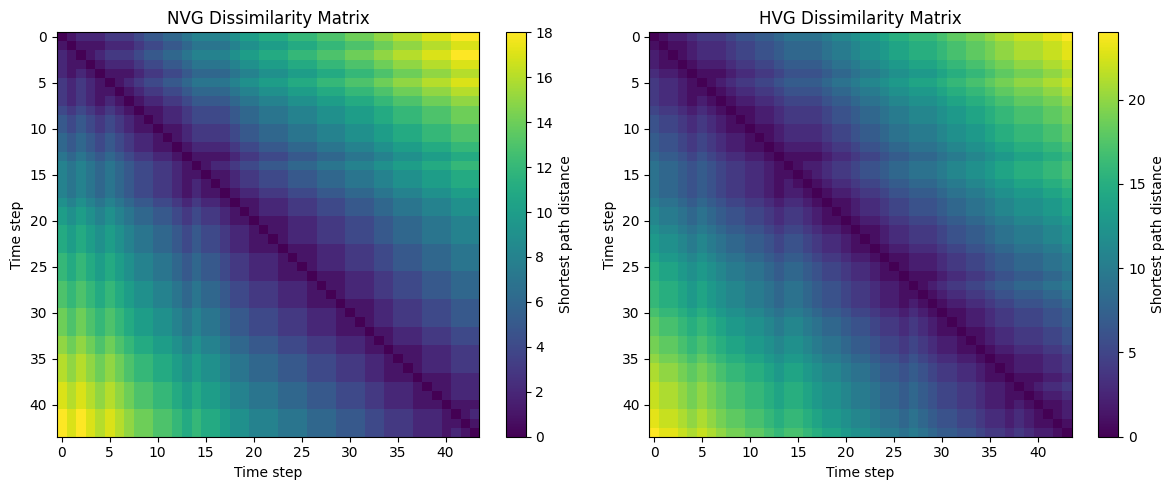

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

for ax, (D, title) in zip(axes, [(D_nvg, 'NVG Dissimilarity Matrix'),
                                   (D_hvg, 'HVG Dissimilarity Matrix')]):
    im = ax.imshow(D, cmap='viridis', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Time step')
    plt.colorbar(im, ax=ax, label='Shortest path distance')
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()

## Observations

Both dissimilarity matrices show the expected **temporal locality** — nearby time steps (dark diagonal band) have small distances, while distant time steps (bright corners) have large distances.

**NVG** has smaller maximum distances than HVG — long-range visibility connections create shortcuts in the graph, reducing shortest path lengths between distant nodes.

**HVG** distances are larger and more uniform — the restricted connectivity produces a more regular distance structure with fewer shortcuts.

These structural differences will produce different persistence diagrams when Vietoris-Rips filtration is applied — the comparison is carried out in Repo 3.

## Saving Dissimilarity Matrices

We save the NVG and HVG dissimilarity matrices for the 2008 crisis window — ready for TDA comparison in Repo 3.

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

np.save('../data/processed/sp500_2008_nvg_dissimilarity.npy', D_nvg)
np.save('../data/processed/sp500_2008_hvg_dissimilarity.npy', D_hvg)

print("Saved:")
print("  ../data/processed/sp500_2008_nvg_dissimilarity.npy")
print("  ../data/processed/sp500_2008_hvg_dissimilarity.npy")

Saved:
  ../data/processed/sp500_2008_nvg_dissimilarity.npy
  ../data/processed/sp500_2008_hvg_dissimilarity.npy


## Conclusions

The visibility graph pipeline is complete for a 44-day window of S&P 500 returns during the 2008 crisis:

| Graph | Edges | Max Distance | Structure |
|-------|-------|-------------|-----------|
| NVG | 75 | 18 | Long-range connections, extreme returns are hubs |
| HVG | 62 | 24 | Local connections, extreme returns are barriers |

Both dissimilarity matrices are saved and ready for Vietoris-Rips filtration in Repo 3.

**Key advantage over Takens embedding:** no parameter selection required — the graph construction is fully deterministic given the time series.

**Key limitation:** $O(n^2)$ construction — computationally prohibitive for long series. Efficient implementations exist (see Güzel 2026)

## References

- Lacasa et al. (2008) — *From time series to complex networks: The visibility graph* — [arxiv.org/abs/0901.0951](https://arxiv.org/abs/0901.0951)
- Güzel (2026) — *Persistent Homology of Time Series through Complex Networks* — [arxiv.org/abs/2605.01624](https://arxiv.org/abs/2605.01624)